In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import znet without installing it
sys.path.append(os.path.abspath('..'))

import torch
import znet
from znet import ZNet, SourceNode, MixingNode, StackNode

print("znet imported successfully")

znet imported successfully


In [2]:
muA = SourceNode(key="mu_A")
model = ZNet(muA)

In [3]:
print(model({'mu_A':[1000,2000]}) == model(mu_A=[1000,2000]))


tensor([[True],
        [True]])


In [4]:
mu_vals = torch.linspace(-20000, 20000, 100).unsqueeze(1) # Shape (100, 1)

inputs = {
    "mu_A": mu_vals, 
    "mu_B": -mu_vals, 
}

In [5]:
muB = SourceNode(key="mu_B")
ideal_mix = StackNode([muA, muB])
ideal_mixed = MixingNode(sub_nodes=[ideal_mix])
omega = ZNet(ideal_mixed)

In [6]:
# 1. Prepare Inputs with Gradients (Essential for Legendre Transform)
# We need derivates dOmega/dmu to get particle counts N
inputs_grad = {
    k: v.clone().detach().requires_grad_(True) 
    for k, v in inputs.items()
}

# 2. Forward Pass: Calculate Grand Potential (Omega)
Omega = omega(inputs_grad)

# 3. Calculate Conjugate Variables (Particle Numbers N)
# Thermodynamics: N_i = - d(Omega) / d(mu_i)
# usage of torch.autograd.grad handles the differentiation
# sum() is needed because .grad() only works on scalar outputs
grads = torch.autograd.grad(
    outputs=Omega.sum(), 
    inputs=list(inputs_grad.values()), 
    create_graph=False
)
# Map gradients back to their keys ('mu_A', 'mu_B')
N_counts = {k: -g for k, g in zip(inputs_grad.keys(), grads)}

# 4. Perform Legendre Transform
# F = Omega + sum(mu_i * N_i)
diff_terms = sum(inputs_grad[k] * N_counts[k] for k in inputs_grad)
Helmholtz_F = Omega.unsqueeze(1) + diff_terms


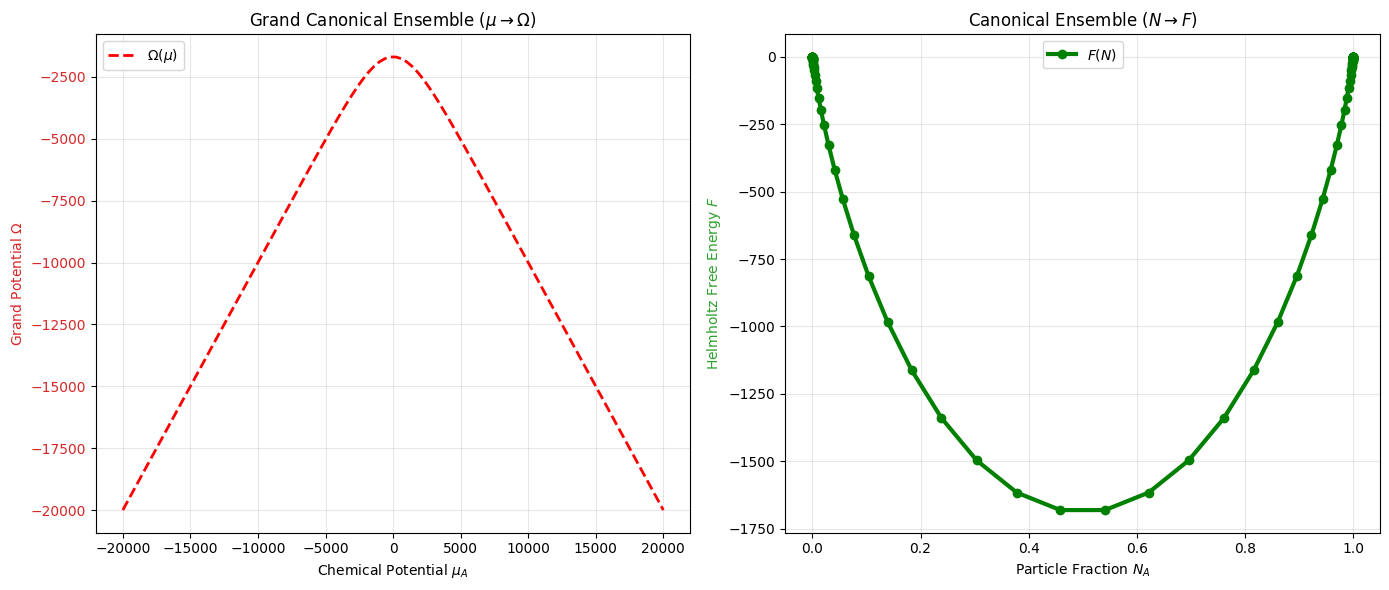

In [7]:
import matplotlib.pyplot as plt
# 5. Visualization
# Flatten() ensures everything is a 1D array for plotting
mu_axis = inputs_grad['mu_A'].detach().numpy().flatten()
y_omega = Omega.detach().numpy().flatten()
y_helmholtz = Helmholtz_F.detach().numpy().flatten()
y_NA = N_counts['mu_A'].detach().numpy().flatten()

# Note: We do not simplify sorting here because F(N) needs N to be the x-axis, 
# and mu might not be monotonic with N in complex systems (though here it is).
sort_idx = mu_axis.argsort()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Grand Potential vs Chemical Potential (Natural Variables)
ax1.set_xlabel(r'Chemical Potential $\mu_A$')
ax1.set_ylabel(r'Grand Potential $\Omega$', color='tab:red')
ax1.plot(mu_axis[sort_idx], y_omega[sort_idx], 'r--', linewidth=2, label=r'$\Omega(\mu)$')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title(r'Grand Canonical Ensemble ($\mu \to \Omega$)')

# Plot 2: Helmholtz Free Energy vs Particle Number (Conjugate Variables)
# Ideally F is plotted against its natural variable N_A
# Sort by N_A for a clean line
sort_N = y_NA.argsort()

ax2.set_xlabel(r'Particle Fraction $N_A$')
ax2.set_ylabel(r'Helmholtz Free Energy $F$', color='tab:green')
ax2.plot(y_NA[sort_N], y_helmholtz[sort_N], 'g-', linewidth=3, label=r'$F(N)$', marker='o')
ax2.legend(loc='upper center')
ax2.grid(True, alpha=0.3)
ax2.set_title(r'Canonical Ensemble ($N \to F$)')

plt.tight_layout()
plt.show()